In [1]:
import xarray as xr
import glob
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
analysis=xr.open_mfdataset(glob.glob('../data/EN4/*analysis*.nc'))

/tmp/ipykernel_2714736/2479073870.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  analysis=xr.open_mfdataset(glob.glob('../data/EN4/*analysis*.nc'))


In [4]:
profiles=xr.open_dataset(glob.glob('../data/EN4/*profiles*.nc')[0])


In [5]:
profiles

<xarray.Dataset> Size: 360MB
Dimensions:                       (N_PROF: 23958, N_CALIB: 1, N_PARAM: 5,
                                   N_LEVELS: 400, N_HISTORY: 0)
Dimensions without coordinates: N_PROF, N_CALIB, N_PARAM, N_LEVELS, N_HISTORY
Data variables: (12/55)
    CALIBRATION_DATE              (N_PROF, N_CALIB, N_PARAM) |S14 2MB ...
    CYCLE_NUMBER                  (N_PROF) int32 96kB ...
    DATA_CENTRE                   (N_PROF) |S2 48kB ...
    DATA_MODE                     (N_PROF) |S1 24kB ...
    DATA_STATE_INDICATOR          (N_PROF) |S4 96kB ...
    DATA_TYPE                     |S16 16B ...
    ...                            ...
    STATION_PARAMETERS            (N_PROF, N_PARAM) |S4 479kB ...
    TEMP                          (N_PROF, N_LEVELS) float32 38MB ...
    WMO_INST_TYPE                 (N_PROF) |S4 96kB ...
    depth_corrections             (N_PROF, N_LEVELS) float32 38MB ...
    instrument_type               (N_PROF) object 192kB ...
    thermal_corrections           (N_PROF) float32 96kB ...
Attributes:
    licence:     EN4 is distributed under the Non Commercial Government Licen...
    references:  Website and paper: https://www.metoffice.gov.uk/hadobs/en4/;...
    history:     Sat Mar 27 12:19:33 2021: ncks -O -x -v TEMP_UNIQUE_ID,PSAL_...
    NCO:         netCDF Operators version 4.7.5 (Homepage = http://nco.sf.net...

ds = analysis.sel(lat=slice(-67,-66),lon=slice(139,145))
ds

Text(0, 0.5, 'Pressure')

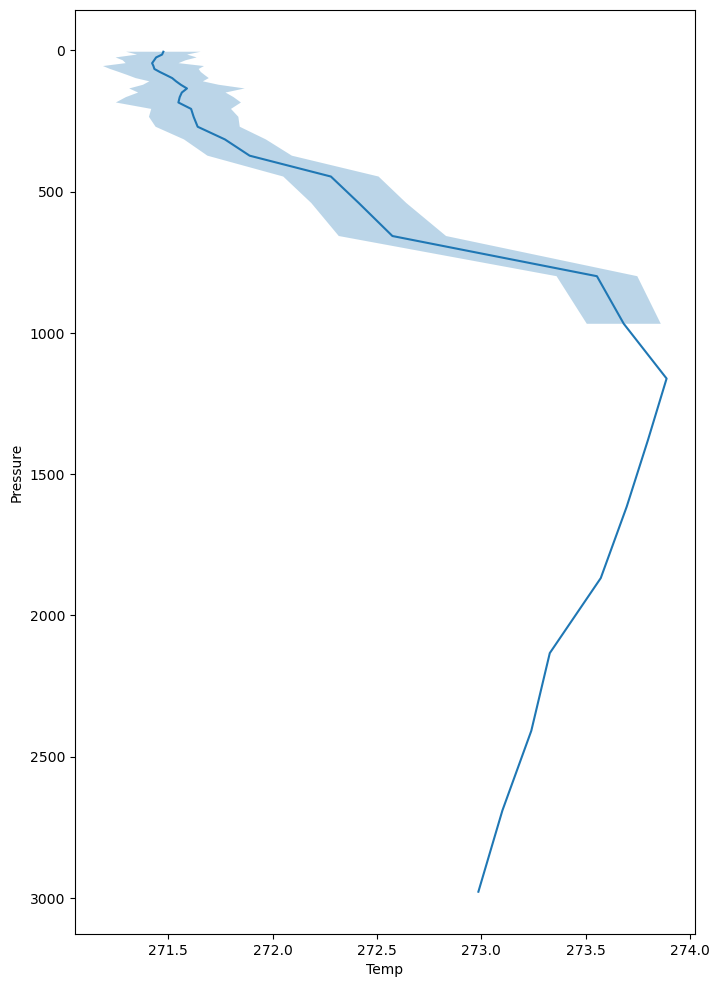

In [10]:

fig, ax = plt.subplots(1,1,figsize=(8,12))


mean_temp = ds.temperature.mean(['time','lat','lon'])
stde_temp = ds.temperature_uncertainty.mean(['time','lat','lon'])



# Mean line
ax.plot(mean_temp, ds.depth)


# Shaded region (choose ONE)
ax.fill_betweenx(ds.depth, mean_temp - stde_temp, mean_temp + stde_temp, alpha=0.3, label='±1 std')

ax.invert_yaxis()
ax.set_xlabel('Temp')
ax.set_ylabel('Pressure')

